## Is the market calibrated? A reliability/calibration check

`overreaction_analysis.ipynb` tests overreaction around discrete goal events, but that design has real costs: it's restricted to first-half goals only (SofaScore's match-minute timestamps can't be mapped to real elapsed time across the halftime break with the data on hand), and it only tests the *sign* of the post-event drift.

This notebook asks a related but different question, using a completely different method: **when the market quotes a given probability, does that outcome actually happen that often?** A price of 0.70 should correspond to that team winning about 70% of the time. If it wins much more or less often than that, the price wasn't a good probability &mdash; which is a direct, standard way to ask whether "large market reactions are justified by new information."

This sidesteps the SofaScore timing problem entirely: everything here is anchored to **minutes before each market's own `close_time`** (Kalshi's own field, no cross-source join, no halftime ambiguity), rather than to match-minute. As a side effect this covers the *entire* window and *all three* markets per match (both teams + the tie), not just first-half goals for the eventual winner &mdash; 312 markets instead of 84 goals.

### Method

For every finalized `KXWCGAME` market (312 = 104 matches &times; 3 outcomes each), take the last traded price at a fixed set of checkpoints counting back from that market's settlement (`close_time`): 180, 150, 120, 90, 60, 30, 15, and 5 minutes before close. Pair each price with the market's eventual settlement (1 if it resolved "yes", 0 otherwise).

Two standard forecast-evaluation tools, computed separately at each checkpoint:

- **Brier score** &mdash; mean squared error between price and the 0/1 outcome. Lower is better; a score of 0 is a perfect forecast, ~0.22 is what you'd get quoting the base rate (1/3) on everything.
- **Reliability diagram** &mdash; bin observations by quoted price, plot each bin's mean price against its *actual* resolution frequency, with a 95% Wilson score interval. Points on the diagonal are well-calibrated; above it means the market was underconfident in that bin, below means overconfident.

**Caveat:** the 3 markets for a given match at a given checkpoint aren't independent draws &mdash; exactly one of the three settles "yes," so their outcomes are negatively correlated with each other. The Wilson intervals below treat each observation as an independent Bernoulli trial, which slightly understates the true uncertainty. Worth revisiting with a clustered/bootstrap CI (resampling whole matches) before leaning on the precise interval widths.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Notebook lives in code/, so data/ and output/ live one level up.
ROOT = Path.cwd().parent
FIG_DIR = ROOT / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINTS = [180, 150, 120, 90, 60, 30, 15, 5]
HIGHLIGHT_CHECKPOINTS = [180, 90, 30, 5]

In [2]:
def wilson_ci(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2)) / denom
    return center - half, center + half


BINS = np.linspace(0, 1, 11)


def reliability_table(checkpoint: int) -> pd.DataFrame:
    sub = obs[obs["checkpoint"] == checkpoint].copy()
    sub["bin"] = pd.cut(sub["price"], BINS, include_lowest=True)
    agg = sub.groupby("bin", observed=True).agg(
        n=("outcome", "size"), k=("outcome", "sum"), mean_price=("price", "mean")
    )
    agg["observed_freq"] = agg["k"] / agg["n"]
    ci = agg.apply(lambda r: wilson_ci(r["k"], r["n"]), axis=1, result_type="expand")
    agg["ci_low"], agg["ci_high"] = ci[0], ci[1]
    return agg.reset_index(drop=True)

In [3]:
markets = pd.read_parquet(ROOT / "data/kalshi/kxwcgame_markets.parquet")
candles = pd.read_parquet(ROOT / "data/kalshi/candlesticks/kxwcgame_minute.parquet")

markets = markets[markets["status"] == "finalized"].copy()
markets["close_time"] = pd.to_datetime(markets["close_time"])
markets["outcome"] = (markets["result"] == "yes").astype(int)
print(f"{len(markets)} finalized markets, base rate = {markets['outcome'].mean():.3f}")

before = len(candles)
candles_merged = candles.merge(markets[["market_ticker", "close_time"]], on="market_ticker")
print(f"candles merge markets: {before} rows -> {len(candles_merged)} rows")
candles_by_ticker = {
    t: g.sort_values("timestamp") for t, g in candles_merged.groupby("market_ticker")
}

rows = []
for m in markets.itertuples():
    grp = candles_by_ticker.get(m.market_ticker)
    if grp is None or grp.empty:
        continue
    for cp in CHECKPOINTS:
        target = m.close_time - pd.Timedelta(minutes=cp)
        before = grp[grp["timestamp"] <= target]
        if before.empty:
            continue
        rows.append(
            {
                "market_ticker": m.market_ticker,
                "checkpoint": cp,
                "price": before["price_close"].iloc[-1],
                "outcome": m.outcome,
            }
        )

obs = pd.DataFrame(rows)
print(f"{len(obs)} price/outcome observations across {len(CHECKPOINTS)} checkpoints")
obs.groupby("checkpoint").size().rename("n").to_frame()

312 finalized markets, base rate = 0.333
candles merge markets: 74754 rows -> 74754 rows


2496 price/outcome observations across 8 checkpoints


,n
checkpoint,
5,312
15,312
30,312
60,312
90,312
120,312
150,312
180,312


In [4]:
obs["sq_err"] = (obs["price"] - obs["outcome"]) ** 2
brier_by_checkpoint = obs.groupby("checkpoint")["sq_err"].mean().sort_index(ascending=False)
brier_by_checkpoint

checkpoint
180    0.166393
150    0.165757
120    0.163113
90     0.160899
60     0.151306
30     0.122791
15     0.083667
5      0.026338
Name: sq_err, dtype: float64

Saved /Users/katemarine/Documents/wc26-prediction-markets/output/figures/calibration.png


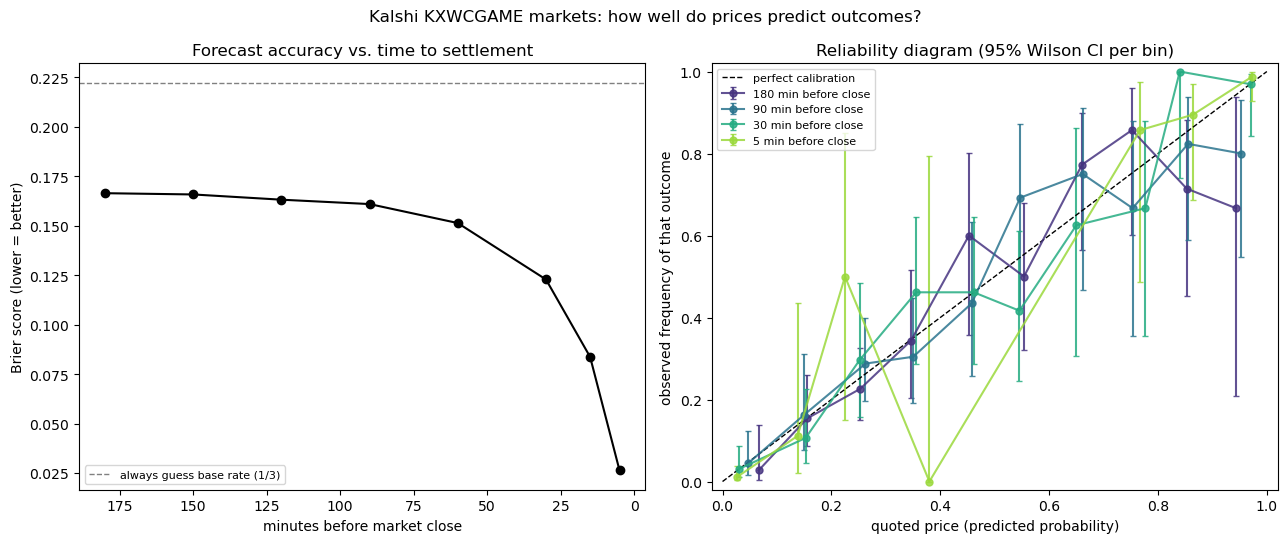

In [5]:
fig, (ax_brier, ax_cal) = plt.subplots(1, 2, figsize=(13, 5.5))

ax_brier.plot(brier_by_checkpoint.index, brier_by_checkpoint.values, marker="o", color="black")
ax_brier.axhline(2 / 9, color="gray", linestyle="--", linewidth=1, label="always guess base rate (1/3)")
ax_brier.set_xlabel("minutes before market close")
ax_brier.set_ylabel("Brier score (lower = better)")
ax_brier.set_title("Forecast accuracy vs. time to settlement")
ax_brier.invert_xaxis()
ax_brier.legend(fontsize=8)

colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(HIGHLIGHT_CHECKPOINTS)))
for cp, color in zip(HIGHLIGHT_CHECKPOINTS, colors):
    tbl = reliability_table(cp)
    err = [tbl["observed_freq"] - tbl["ci_low"], tbl["ci_high"] - tbl["observed_freq"]]
    ax_cal.errorbar(
        tbl["mean_price"], tbl["observed_freq"], yerr=err, fmt="o-", color=color,
        label=f"{cp} min before close", capsize=2, markersize=5, alpha=0.85,
    )
ax_cal.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1, label="perfect calibration")
ax_cal.set_xlabel("quoted price (predicted probability)")
ax_cal.set_ylabel("observed frequency of that outcome")
ax_cal.set_title("Reliability diagram (95% Wilson CI per bin)")
ax_cal.legend(fontsize=8, loc="upper left")
ax_cal.set_xlim(-0.02, 1.02)
ax_cal.set_ylim(-0.02, 1.02)

fig.suptitle("Kalshi KXWCGAME markets: how well do prices predict outcomes?")
fig.tight_layout()
out_path = FIG_DIR / "calibration.png"
fig.savefig(out_path, dpi=150)
print(f"Saved {out_path}")

### Results so far

**Brier score improves smoothly and monotonically** from 0.166 at 3 hours before close down to 0.026 at 5 minutes before close &mdash; and sits well below the "always guess the 1/3 base rate" benchmark (0.222) at every single checkpoint, even the earliest. The market is informative from very early on, not just in the closing minutes, and gets steadily more accurate as more of the match is known &mdash; exactly what an efficient, rational market should look like.

**The reliability diagram tracks the diagonal reasonably well at all four highlighted horizons** (180/90/30/5 min before close), with no consistent, one-directional departure from perfect calibration &mdash; i.e. no persistent over- or under-confidence bias jumps out. The error bars are wide (a few hundred observations split across ~10 bins &times; 4 checkpoints means some bins have only a handful of markets in them), so individual bin wiggles shouldn't be over-read, but there's nothing here suggesting the market is systematically miscalibrated.

**How this connects to the other two notebooks:** taken together with `overreaction_analysis.ipynb` finding no reversion after goals, and `regression_analysis.ipynb` finding price tracks the actual result more than xG, this is a third, independent line of evidence pointing the same way &mdash; nothing so far suggests the market is overreacting or irrational. That said, this notebook and the goal event-study are answering *related but distinct* questions: Brier score and calibration describe the market's accuracy and bias *on average, at a point in time*; they don't directly test whether a *specific large move* was later given back. A market can be well-calibrated in the aggregate while still overreacting to some events and underreacting to others in ways that cancel out. The goal-level event study is still the more direct test of that; this is complementary, broader-coverage evidence, not a replacement for it.

**Limitations / next steps:**

- The 3 markets per match aren't independent (see the caveat above) &mdash; the Wilson intervals are a bit too narrow. A cluster-bootstrap (resample whole matches, not individual markets) would give more honest uncertainty.
- Only regulation-time `KXWCGAME` markets are included here; the `KXMENWORLDCUP` tournament-winner futures (hourly candles, already pulled) would let the same method run over a much longer horizon.
- Worth checking whether calibration differs by round (group stage vs. knockout) or by how lopsided the pre-match favorite was &mdash; right now everything is pooled.